# Раскрытие посадочной опоры
Лабораторная работа 4

Выполнил Любушкин Е.И.

# Задание

Определите угловую скорость опорного подкоса при раскрытии
посадочной опоры при следующий параметрах посадочной опоры и
начальных условиях:
масса опорного подкоса mAB = 250 кг;
масса телескопического подкоса mB = 150 кг;
длина опорного подкоса l = 6.5 м;
конечная длина телескопического подкоса sk = 8 м;
конечный угол поворота опорного подкоса φk = 120 градусов;
начальная угловая скорость подкоса φ˙(0) = 5 град/c (при φ0 = 0);
nx = 1.
Оцените максимальную силу растяжения телескопического подкоса
после раскрытия опоры: считая, что в момент полного раскрытия
опоры он имеет жесткость на растяжение c = 105 Н/м.


## Решение задачи

Угол phi_k не достигнут
Время достижения phi_k: 20.000 с
Угловая скорость в этот момент: 0.0208 рад/с (1.19 град/с)
Скорость удлинения подкоса при phi_k: 0.0745 м/с
Максимальная сила растяжения: 166.49 Н


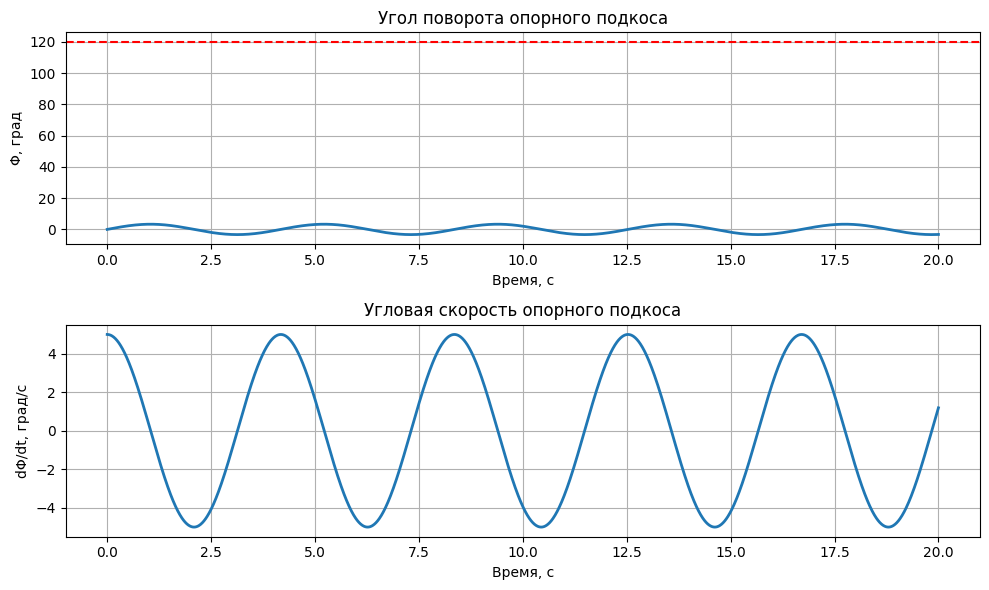

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Параметры
m_OB = 250  # масса опорного подкоса, кг
m_AB = 150  # масса телескопического подкоса, кг
l = 6.5  # длина опорного подкоса, м
s_k = 8  # конечная длина телескопического подкоса, м
phi_k_deg = 120  # конечный угол поворота, град
phi0_deg = 0  # начальный угол, град
dphi0_deg = 5  # начальная скорость, град/с
n_x = 1 
g = 9.81  
c = 1e5  

# Перевод
phi0 = np.deg2rad(phi0_deg)
dphi0 = np.deg2rad(dphi0_deg)
phi_k = np.deg2rad(phi_k_deg)

# Коэффициент масс
k = m_AB / m_OB

# Учет момента инерции всей системы
J = (m_OB + m_AB) * l**2 / 3


def ode_rhs(t, y):
    # y[0] = phi, y[1] = dphi/dt
    return [y[1], -(3 / 2) * (n_x * g / l) * np.sin(y[0])]


y0 = [phi0, dphi0]

# Интегрирование
t_span = (0, 20)
sol = solve_ivp(ode_rhs, t_span, y0, max_step=0.01, rtol=1e-8, atol=1e-10)
phi = sol.y[0]
omega = sol.y[1]
t = sol.t

# Поиск индекса, где phi >= phi_k
try:
    idx_k = np.where(phi >= phi_k)[0][0]
    t_k = t[idx_k]
    omega_k = omega[idx_k]
except IndexError:
    print("Угол phi_k не достигнут")
    t_k, omega_k = t[-1], omega[-1]

print(f"Время достижения phi_k: {t_k:.3f} с")
print(f"Угловая скорость в этот момент: {omega_k:.4f} рад/с ({np.rad2deg(omega_k):.2f} град/с)")

# Расчет максимальной силы растяжения телескопа
zeta = s_k / l
eta_k = np.sqrt(1 + zeta**2 - 2 * zeta * np.cos(phi_k))
ds_dt_k = l * (zeta / eta_k) * np.sin(phi_k) * omega_k
m_AB_eff = m_AB / 3
x_max = abs(ds_dt_k) * np.sqrt(m_AB_eff / c)
F_max = c * x_max

print(f"Скорость удлинения подкоса при phi_k: {ds_dt_k:.4f} м/с")
print(f"Максимальная сила растяжения: {F_max:.2f} Н")

# Графики
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, np.rad2deg(phi), lw=2)
plt.axhline(phi_k_deg, color="r", ls="--")
plt.xlabel("Время, с")
plt.ylabel("Φ, град")
plt.title("Угол поворота опорного подкоса")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, np.rad2deg(omega), lw=2)
plt.xlabel("Время, с")
plt.ylabel("dΦ/dt, град/с")
plt.title("Угловая скорость опорного подкоса")
plt.grid(True)
plt.tight_layout()
plt.show()

phi_90 = np.deg2rad(90)
try:
    idx_90 = np.where(phi >= phi_90)[0][0]
    omega_90 = omega[idx_90]
    print(
        f"Угловая скорость при φ=90°: {omega_90:.4f} рад/с ({np.rad2deg(omega_90):.2f} град/с)"
    )
except IndexError:
    pass
